# VIX Open Threshold Analysis — S1 Straddle Performance
Visualise long and short straddle P&L across VIX open ranges to heuristically determine optimal entry thresholds.  
Current gates: **short** only when `vix_open > 19`, **long** only when `vix_open < 20`.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=0.95)

# ── Load data ──────────────────────────────────────────────────────────────
tl  = pd.read_parquet("results/trade_log_net_slip25.parquet")
ext = pd.read_parquet("data/external_data.parquet")
ext["date"] = pd.to_datetime(ext["date"]).dt.date

# Attach vix_open to each trade by entry date
tl["entry_date"] = pd.to_datetime(tl["entry_time"]).dt.date
tl = tl.merge(ext[["date", "vix_open"]], left_on="entry_date", right_on="date", how="left")

# ── VIX buckets ────────────────────────────────────────────────────────────
VIX_BINS   = [0,  17,  19,  21,  23, 100]
VIX_LABELS = ["<17", "17–19", "19–21", "21–23", ">23"]
tl["vix_bin"] = pd.cut(tl["vix_open"], bins=VIX_BINS, labels=VIX_LABELS)

print(f"Trades loaded : {len(tl)}  |  Short: {(tl['side']=='short').sum()}  |  Long: {(tl['side']=='long').sum()}")
print(f"VIX open range: {tl['vix_open'].min():.1f} – {tl['vix_open'].max():.1f}")
print()
print("Trade count by VIX bucket × side:")
print(tl.groupby(["vix_bin","side"], observed=True).size().unstack(fill_value=0).to_string())

Trades loaded : 142  |  Short: 65  |  Long: 77
VIX open range: 18.1 – 35.1

Trade count by VIX bucket × side:
side     long  short
vix_bin             
17–19       2      2
19–21      26     13
21–23      15      4
>23        31     40


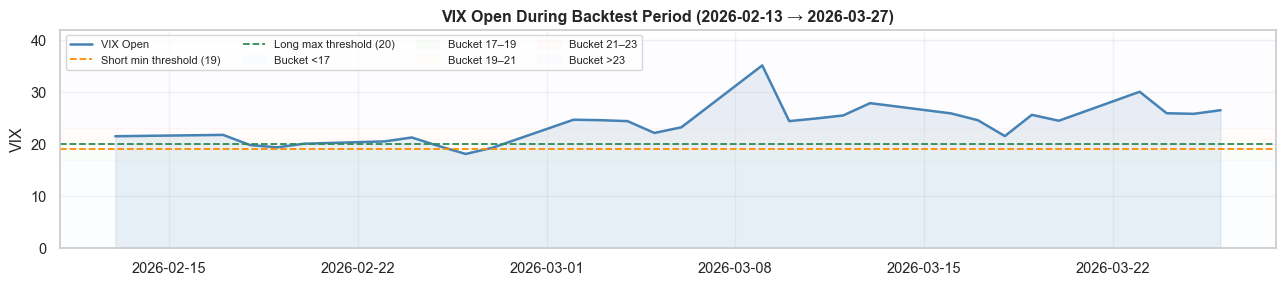

In [6]:
# ── VIX open time series with current threshold lines ─────────────────────
vix_period = ext[
    ext["date"].between(pd.Timestamp("2026-02-13").date(), pd.Timestamp("2026-03-27").date())
].copy()

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(pd.to_datetime(vix_period["date"]), vix_period["vix_open"],
        color="steelblue", linewidth=1.8, label="VIX Open")
ax.fill_between(pd.to_datetime(vix_period["date"]), vix_period["vix_open"],
                alpha=0.12, color="steelblue")
ax.axhline(19, color="darkorange", linestyle="--", linewidth=1.3, label="Short min threshold (19)")
ax.axhline(20, color="seagreen",   linestyle="--", linewidth=1.3, label="Long max threshold (20)")

# Shade bucket bands
for lo, hi, lbl, c in zip(VIX_BINS[:-1], VIX_BINS[1:], VIX_LABELS,
                           ["#d4efff","#cce5cc","#fff3cd","#ffd6cc","#e8d5f5"]):
    ax.axhspan(lo, min(hi, 40), alpha=0.07, color=c, label=f"Bucket {lbl}")

ax.set_title("VIX Open During Backtest Period (2026-02-13 → 2026-03-27)", fontweight="bold")
ax.set_ylabel("VIX"); ax.set_xlabel("")
ax.legend(fontsize=8, ncol=4, loc="upper left")
ax.grid(True, alpha=0.25)
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

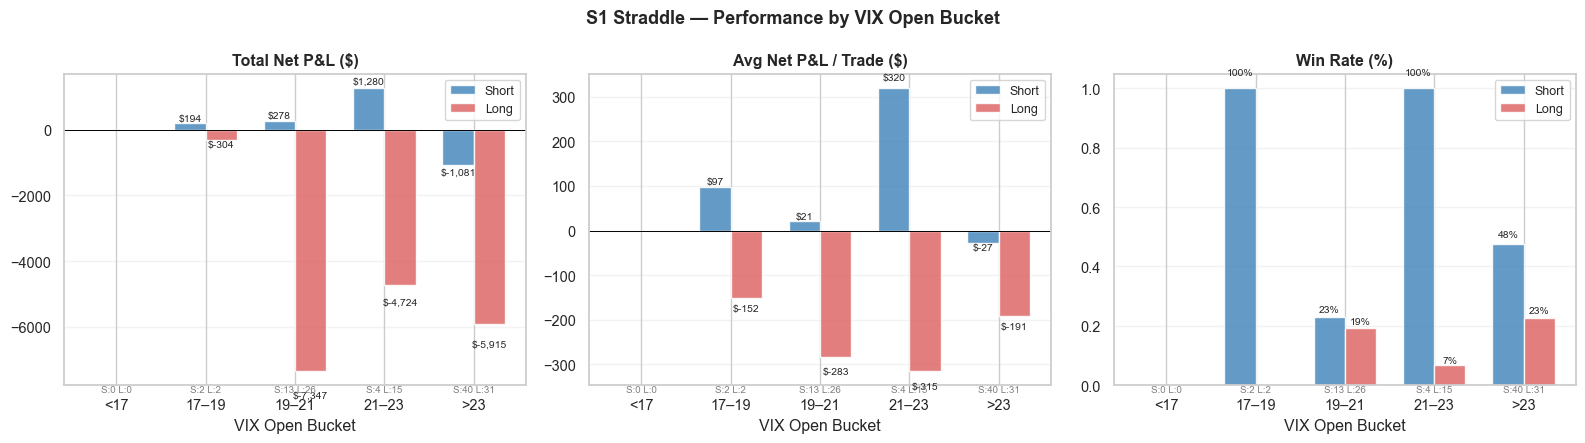

vix_bin  side    total_pnl     avg_pnl  n_trades  win_rate
  17–19  long  -303.715365 -151.857682         2  0.000000
  17–19 short   193.601709   96.800855         2  1.000000
  19–21  long -7347.327930 -282.589536        26  0.192308
  19–21 short   277.899300   21.376869        13  0.230769
  21–23  long -4723.519433 -314.901296        15  0.066667
  21–23 short  1280.207513  320.051878         4  1.000000
    >23  long -5915.332963 -190.817192        31  0.225806
    >23 short -1080.924213  -27.023105        40  0.475000


In [7]:
# ── Total P&L / Avg P&L per trade / Win rate  ×  VIX bucket × side ────────
summary = (
    tl.groupby(["vix_bin", "side"], observed=True)["pnl_net"]
    .agg(
        total_pnl = "sum",
        avg_pnl   = "mean",
        n_trades  = "count",
        win_rate  = lambda x: (x > 0).mean(),
    )
    .reset_index()
)

metrics = [
    ("total_pnl", "Total Net P&L ($)",        "${:,.0f}"),
    ("avg_pnl",   "Avg Net P&L / Trade ($)",   "${:,.0f}"),
    ("win_rate",  "Win Rate (%)",               "{:.0%}"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
palette = {"short": "#4e8cbe", "long": "#e06c6c"}
x_vals  = np.arange(len(VIX_LABELS))
w = 0.35

for ax, (col, title, fmt) in zip(axes, metrics):
    pivot = summary.pivot(index="vix_bin", columns="side", values=col).reindex(VIX_LABELS)
    for offset, side in zip([-w/2, w/2], ["short", "long"]):
        vals = pivot.get(side, pd.Series(dtype=float)).fillna(0).values
        bars = ax.bar(x_vals + offset, vals, w, label=side.capitalize(),
                      color=palette[side], alpha=0.88, edgecolor="white")
        for bar, v in zip(bars, vals):
            if v == 0: continue
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + (abs(v)*0.04 if v >= 0 else -abs(v)*0.08),
                    fmt.format(v), ha="center",
                    va="bottom" if v >= 0 else "top", fontsize=7.5)

    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_xticks(x_vals); ax.set_xticklabels(VIX_LABELS)
    ax.set_xlabel("VIX Open Bucket"); ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, axis="y", alpha=0.25)

    # Annotate trade counts below x-axis
    for i, bucket in enumerate(VIX_LABELS):
        n_s = int(summary.query("vix_bin==@bucket and side=='short'")["n_trades"].sum())
        n_l = int(summary.query("vix_bin==@bucket and side=='long'")["n_trades"].sum())
        ax.text(i, ax.get_ylim()[0], f"S:{n_s} L:{n_l}",
                ha="center", va="top", fontsize=7, color="gray")

fig.suptitle("S1 Straddle — Performance by VIX Open Bucket", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()
print(summary.to_string(index=False))

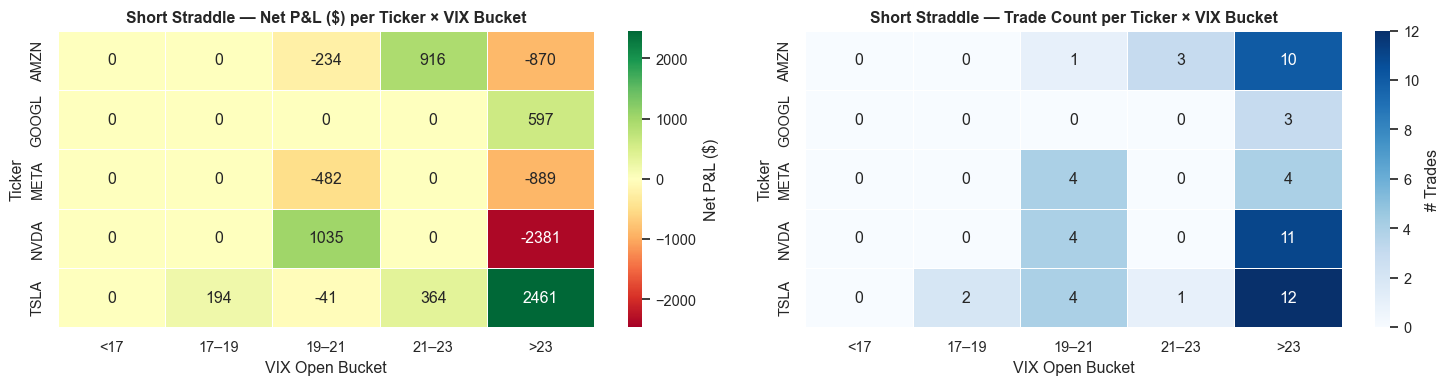

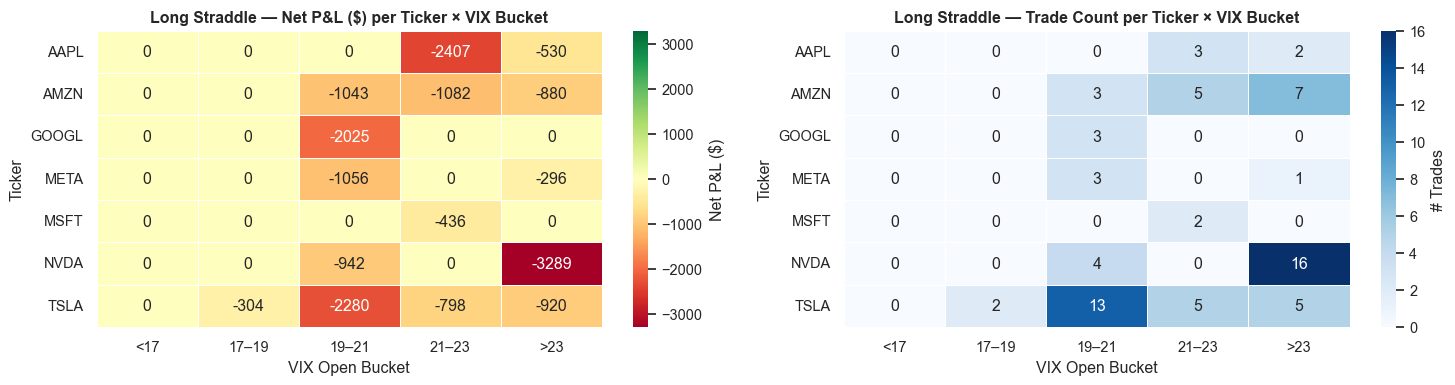

In [8]:
# ── Per-ticker heatmaps: total P&L and trade count (short & long) ──────────
for side, title_pfx in [("short", "Short Straddle"), ("long", "Long Straddle")]:
    sub = tl[tl["side"] == side]
    if sub.empty:
        print(f"No {side} trades found"); continue

    pnl_pivot = (
        sub.groupby(["ticker", "vix_bin"], observed=True)["pnl_net"]
        .sum().unstack(fill_value=0).reindex(columns=VIX_LABELS, fill_value=0)
    )
    cnt_pivot = (
        sub.groupby(["ticker", "vix_bin"], observed=True).size()
        .unstack(fill_value=0).reindex(columns=VIX_LABELS, fill_value=0)
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # P&L heatmap
    vmax = max(abs(pnl_pivot.values.max()), abs(pnl_pivot.values.min()), 1)
    sns.heatmap(pnl_pivot, annot=True, fmt=".0f", cmap="RdYlGn", center=0,
                vmin=-vmax, vmax=vmax, linewidths=0.4, ax=axes[0],
                cbar_kws={"label": "Net P&L ($)"})
    axes[0].set_title(f"{title_pfx} — Net P&L ($) per Ticker × VIX Bucket", fontweight="bold")
    axes[0].set_xlabel("VIX Open Bucket"); axes[0].set_ylabel("Ticker")

    # Count heatmap
    sns.heatmap(cnt_pivot, annot=True, fmt="d", cmap="Blues", linewidths=0.4,
                ax=axes[1], cbar_kws={"label": "# Trades"})
    axes[1].set_title(f"{title_pfx} — Trade Count per Ticker × VIX Bucket", fontweight="bold")
    axes[1].set_xlabel("VIX Open Bucket"); axes[1].set_ylabel("Ticker")

    fig.tight_layout()
    plt.show()

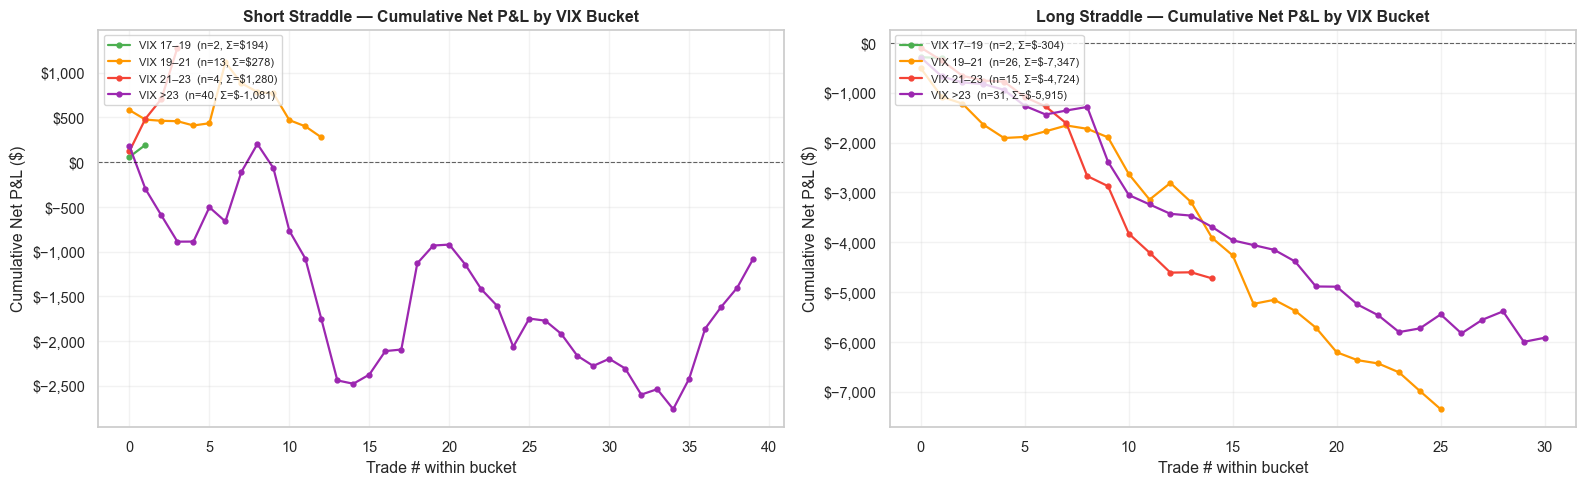

In [9]:
# ── Cumulative P&L by VIX bucket (short & long side, separate panels) ──────
bucket_colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336", "#9C27B0"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, side in zip(axes, ["short", "long"]):
    sub = tl[tl["side"] == side].sort_values("entry_time")
    any_plotted = False
    for color, bucket in zip(bucket_colors, VIX_LABELS):
        bucket_trades = sub[sub["vix_bin"] == bucket]
        if bucket_trades.empty:
            continue
        cum = bucket_trades["pnl_net"].cumsum().reset_index(drop=True)
        ax.plot(range(len(cum)), cum.values,
                marker="o", markersize=3.5, linewidth=1.6,
                label=f"VIX {bucket}  (n={len(bucket_trades)}, Σ=${cum.iloc[-1]:,.0f})",
                color=color)
        any_plotted = True

    if not any_plotted:
        ax.text(0.5, 0.5, "No trades", ha="center", va="center", transform=ax.transAxes)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_title(f"{'Short' if side=='short' else 'Long'} Straddle — Cumulative Net P&L by VIX Bucket",
                 fontweight="bold")
    ax.set_xlabel("Trade # within bucket"); ax.set_ylabel("Cumulative Net P&L ($)")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.25)

fig.tight_layout()
plt.show()

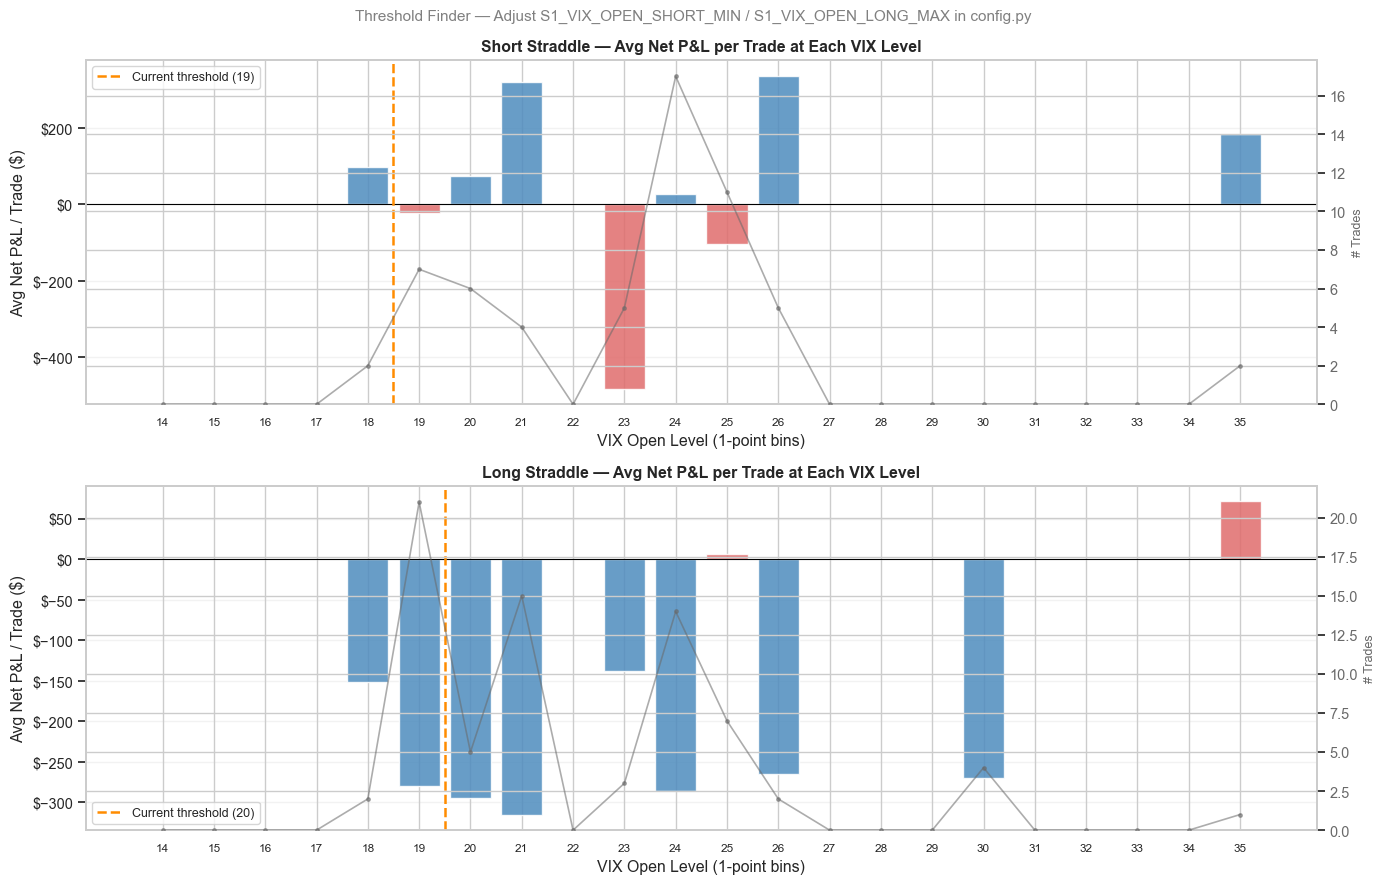

In [10]:
# ── Fine-grained avg P&L per trade vs VIX level — threshold finder ─────────
# Use 1-point wide bins to show signal quality at every VIX level.
# Orange dashed line = current threshold. Adjust thresholds in config.py based on
# where avg P&L crosses zero (or a desired floor).

FINE_LO, FINE_HI = 14, 36
fine_bins   = list(range(FINE_LO, FINE_HI + 1))
fine_labels = [f"{v}" for v in range(FINE_LO, FINE_HI)]
tl["vix_bin_fine"] = pd.cut(tl["vix_open"], bins=fine_bins, labels=fine_labels, right=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
CURRENT_THRESH = {"short": 19.0, "long": 20.0}
SIDE_COLOR     = {"short": "#4e8cbe", "long": "#e06c6c"}

for ax, side in zip(axes, ["short", "long"]):
    sub   = tl[tl["side"] == side]
    stats = (
        sub.groupby("vix_bin_fine", observed=True)["pnl_net"]
        .agg(avg_pnl="mean", n="count")
        .reindex(fine_labels)
        .reset_index()
    )

    xs    = np.arange(len(stats))
    bar_c = [SIDE_COLOR[side] if (v is not None and not np.isnan(v) and v >= 0)
             else "#dddddd" if (v is None or np.isnan(v))
             else "#e06c6c" if side == "short" else "#4e8cbe"
             for v in stats["avg_pnl"]]
    ax.bar(xs, stats["avg_pnl"].fillna(0), color=bar_c, alpha=0.85, edgecolor="white", zorder=2)

    # Trade count on secondary axis
    ax2 = ax.twinx()
    ax2.plot(xs, stats["n"].fillna(0), color="dimgray", linewidth=1.2,
             marker=".", markersize=5, alpha=0.55, label="# Trades", zorder=3)
    ax2.set_ylabel("# Trades", color="dimgray", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="dimgray")
    ax2.set_ylim(bottom=0)

    # Current threshold line
    thresh = CURRENT_THRESH[side]
    thresh_idx = next((i for i, lbl in enumerate(stats["vix_bin_fine"])
                       if lbl is not None and float(lbl) >= thresh), None)
    if thresh_idx is not None:
        ax.axvline(thresh_idx - 0.5, color="darkorange", linestyle="--",
                   linewidth=1.8, zorder=4, label=f"Current threshold ({thresh:.0f})")

    ax.axhline(0, color="black", linewidth=0.8, zorder=3)
    ax.set_xticks(xs)
    ax.set_xticklabels(stats["vix_bin_fine"], rotation=0, fontsize=8.5)
    ax.set_xlabel("VIX Open Level (1-point bins)")
    ax.set_ylabel("Avg Net P&L / Trade ($)")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    ax.set_title(
        f"{'Short' if side=='short' else 'Long'} Straddle — Avg Net P&L per Trade at Each VIX Level",
        fontweight="bold"
    )
    ax.grid(True, axis="y", alpha=0.25, zorder=1)
    ax.legend(fontsize=9, loc="upper left" if side == "short" else "lower left")

fig.suptitle("Threshold Finder — Adjust S1_VIX_OPEN_SHORT_MIN / S1_VIX_OPEN_LONG_MAX in config.py",
             fontsize=11, color="gray")
fig.tight_layout()
plt.show()

---
# VIX Open Threshold Analysis — In-Sample Period Only
Same analysis as above, restricted to **in-sample data (2026-02-13 → 2026-02-27)**.  
Use this to assess whether the current VIX thresholds were well-calibrated on the IS window, and whether IS performance is driven by specific VIX regimes.

In [11]:
# In-sample window: 2026-02-13 → 2026-02-27 (~10 trading days)
IS_START = pd.Timestamp("2026-02-13").date()
IS_STOP  = pd.Timestamp("2026-02-27").date()

tl_is = tl[tl["entry_date"].between(IS_START, IS_STOP)].copy()

print(f"In-sample window : {IS_START}  →  {IS_STOP}")
print(f"IS trades  : {len(tl_is)}  |  Short: {(tl_is['side']=='short').sum()}  |  Long: {(tl_is['side']=='long').sum()}")
if not tl_is.empty:
    print(f"VIX range  : {tl_is['vix_open'].min():.1f} – {tl_is['vix_open'].max():.1f}")
print()
print("IS trade count by VIX bucket × side:")
print(tl_is.groupby(["vix_bin", "side"], observed=True).size().unstack(fill_value=0).to_string())

In-sample window : 2026-02-13  →  2026-02-27
IS trades  : 66  |  Short: 23  |  Long: 43
VIX range  : 18.1 – 21.7

IS trade count by VIX bucket × side:
side     long  short
vix_bin             
17–19       2      2
19–21      26     13
21–23      15      4


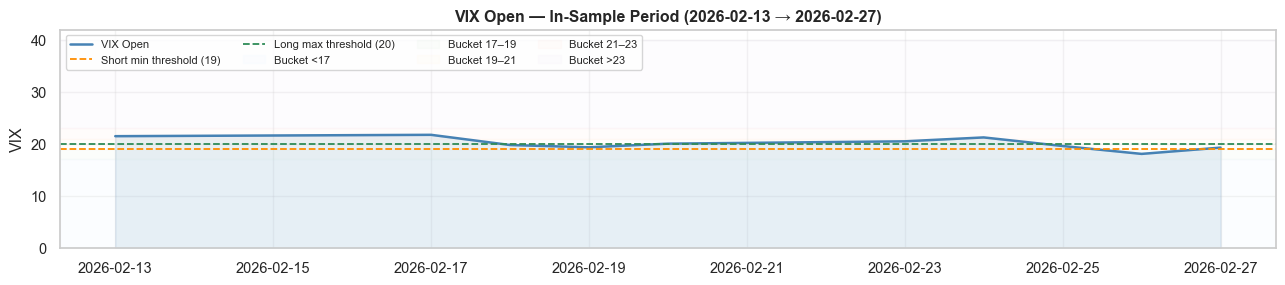

In [12]:
# ── IS: VIX open time series ───────────────────────────────────────────────
vix_is = ext[ext["date"].between(IS_START, IS_STOP)].copy()

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(pd.to_datetime(vix_is["date"]), vix_is["vix_open"],
        color="steelblue", linewidth=1.8, label="VIX Open")
ax.fill_between(pd.to_datetime(vix_is["date"]), vix_is["vix_open"],
                alpha=0.12, color="steelblue")
ax.axhline(19, color="darkorange", linestyle="--", linewidth=1.3, label="Short min threshold (19)")
ax.axhline(20, color="seagreen",   linestyle="--", linewidth=1.3, label="Long max threshold (20)")

for lo, hi, lbl, c in zip(VIX_BINS[:-1], VIX_BINS[1:], VIX_LABELS,
                           ["#d4efff","#cce5cc","#fff3cd","#ffd6cc","#e8d5f5"]):
    ax.axhspan(lo, min(hi, 40), alpha=0.07, color=c, label=f"Bucket {lbl}")

ax.set_title("VIX Open — In-Sample Period (2026-02-13 → 2026-02-27)", fontweight="bold")
ax.set_ylabel("VIX")
ax.legend(fontsize=8, ncol=4, loc="upper left")
ax.grid(True, alpha=0.25)
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

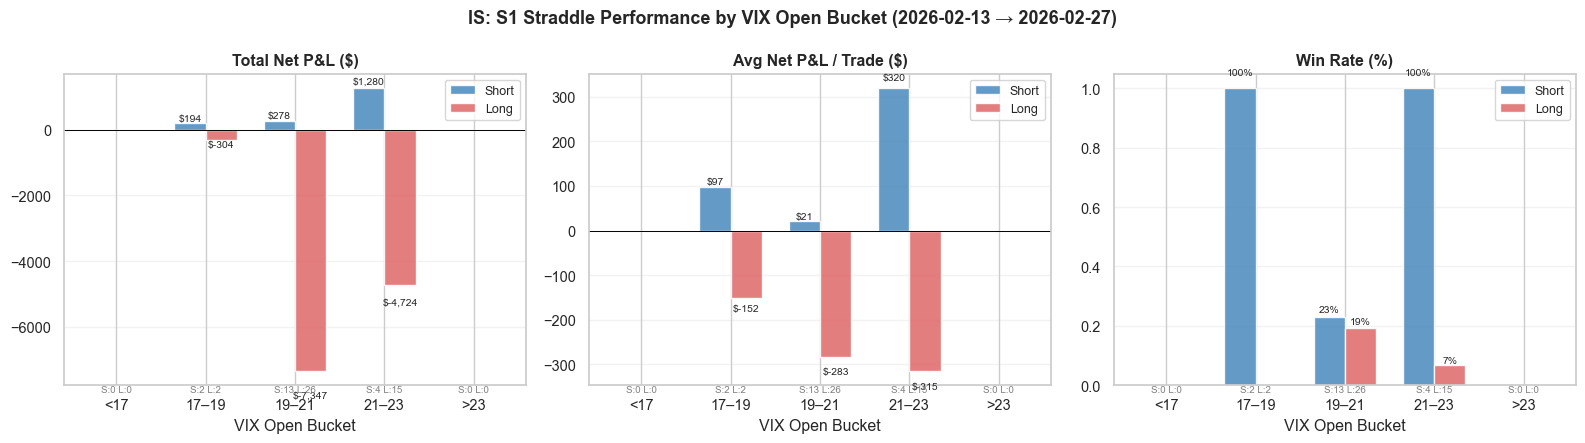

vix_bin  side    total_pnl     avg_pnl  n_trades  win_rate
  17–19  long  -303.715365 -151.857682         2  0.000000
  17–19 short   193.601709   96.800855         2  1.000000
  19–21  long -7347.327930 -282.589536        26  0.192308
  19–21 short   277.899300   21.376869        13  0.230769
  21–23  long -4723.519433 -314.901296        15  0.066667
  21–23 short  1280.207513  320.051878         4  1.000000


In [13]:
# ── IS: Total P&L / Avg P&L per trade / Win rate  ×  VIX bucket × side ────
summary_is = (
    tl_is.groupby(["vix_bin", "side"], observed=True)["pnl_net"]
    .agg(
        total_pnl = "sum",
        avg_pnl   = "mean",
        n_trades  = "count",
        win_rate  = lambda x: (x > 0).mean(),
    )
    .reset_index()
)

metrics = [
    ("total_pnl", "Total Net P&L ($)",       "${:,.0f}"),
    ("avg_pnl",   "Avg Net P&L / Trade ($)",  "${:,.0f}"),
    ("win_rate",  "Win Rate (%)",              "{:.0%}"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
palette = {"short": "#4e8cbe", "long": "#e06c6c"}
x_vals  = np.arange(len(VIX_LABELS))
w = 0.35

for ax, (col, title, fmt) in zip(axes, metrics):
    pivot = summary_is.pivot(index="vix_bin", columns="side", values=col).reindex(VIX_LABELS)
    for offset, side in zip([-w/2, w/2], ["short", "long"]):
        vals = pivot.get(side, pd.Series(dtype=float)).fillna(0).values
        bars = ax.bar(x_vals + offset, vals, w, label=side.capitalize(),
                      color=palette[side], alpha=0.88, edgecolor="white")
        for bar, v in zip(bars, vals):
            if v == 0: continue
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + (abs(v)*0.04 if v >= 0 else -abs(v)*0.08),
                    fmt.format(v), ha="center",
                    va="bottom" if v >= 0 else "top", fontsize=7.5)

    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_xticks(x_vals); ax.set_xticklabels(VIX_LABELS)
    ax.set_xlabel("VIX Open Bucket"); ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, axis="y", alpha=0.25)

    for i, bucket in enumerate(VIX_LABELS):
        n_s = int(summary_is.query("vix_bin==@bucket and side=='short'")["n_trades"].sum())
        n_l = int(summary_is.query("vix_bin==@bucket and side=='long'")["n_trades"].sum())
        ax.text(i, ax.get_ylim()[0], f"S:{n_s} L:{n_l}",
                ha="center", va="top", fontsize=7, color="gray")

fig.suptitle("IS: S1 Straddle Performance by VIX Open Bucket (2026-02-13 → 2026-02-27)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()
print(summary_is.to_string(index=False))

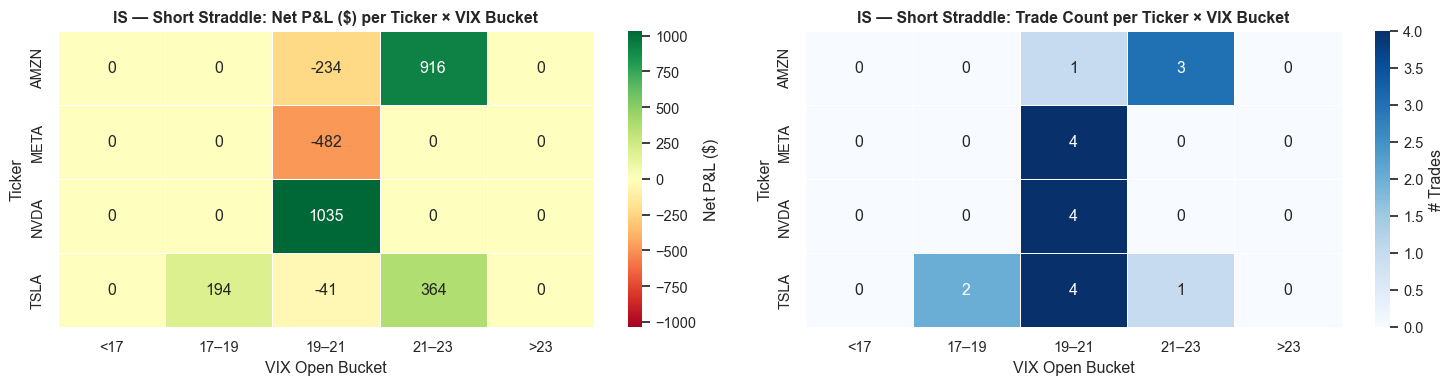

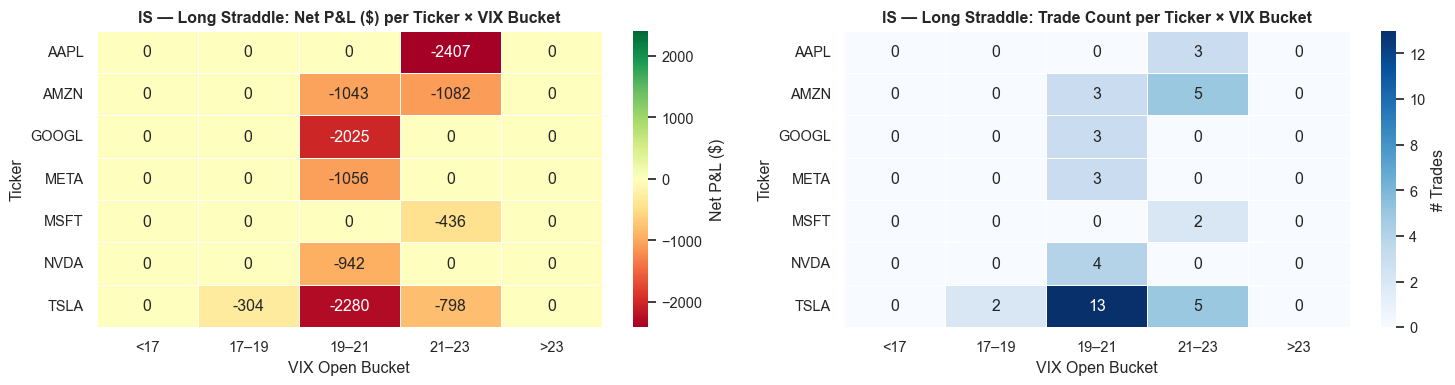

In [14]:
# ── IS: Per-ticker heatmaps ────────────────────────────────────────────────
for side, title_pfx in [("short", "Short Straddle"), ("long", "Long Straddle")]:
    sub = tl_is[tl_is["side"] == side]
    if sub.empty:
        print(f"IS: No {side} trades"); continue

    pnl_pivot = (
        sub.groupby(["ticker", "vix_bin"], observed=True)["pnl_net"]
        .sum().unstack(fill_value=0).reindex(columns=VIX_LABELS, fill_value=0)
    )
    cnt_pivot = (
        sub.groupby(["ticker", "vix_bin"], observed=True).size()
        .unstack(fill_value=0).reindex(columns=VIX_LABELS, fill_value=0)
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    vmax = max(abs(pnl_pivot.values.max()), abs(pnl_pivot.values.min()), 1)
    sns.heatmap(pnl_pivot, annot=True, fmt=".0f", cmap="RdYlGn", center=0,
                vmin=-vmax, vmax=vmax, linewidths=0.4, ax=axes[0],
                cbar_kws={"label": "Net P&L ($)"})
    axes[0].set_title(f"IS — {title_pfx}: Net P&L ($) per Ticker × VIX Bucket", fontweight="bold")
    axes[0].set_xlabel("VIX Open Bucket"); axes[0].set_ylabel("Ticker")

    sns.heatmap(cnt_pivot, annot=True, fmt="d", cmap="Blues", linewidths=0.4,
                ax=axes[1], cbar_kws={"label": "# Trades"})
    axes[1].set_title(f"IS — {title_pfx}: Trade Count per Ticker × VIX Bucket", fontweight="bold")
    axes[1].set_xlabel("VIX Open Bucket"); axes[1].set_ylabel("Ticker")

    fig.tight_layout()
    plt.show()

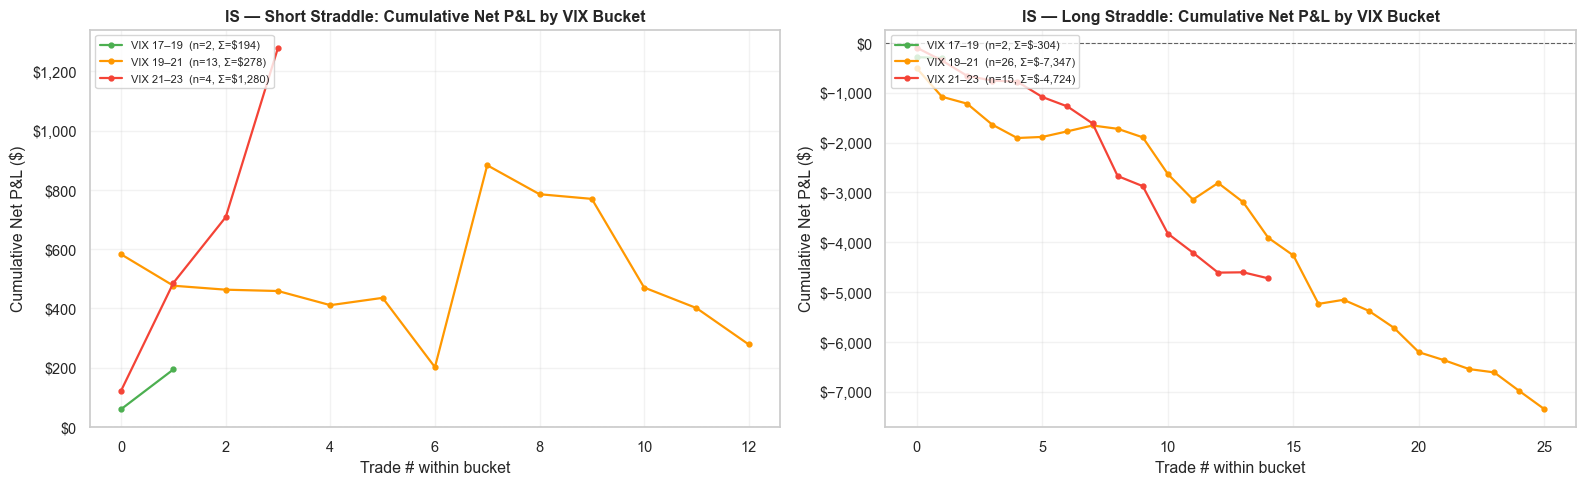

In [15]:
# ── IS: Cumulative P&L by VIX bucket ──────────────────────────────────────
bucket_colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336", "#9C27B0"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, side in zip(axes, ["short", "long"]):
    sub = tl_is[tl_is["side"] == side].sort_values("entry_time")
    any_plotted = False
    for color, bucket in zip(bucket_colors, VIX_LABELS):
        bucket_trades = sub[sub["vix_bin"] == bucket]
        if bucket_trades.empty:
            continue
        cum = bucket_trades["pnl_net"].cumsum().reset_index(drop=True)
        ax.plot(range(len(cum)), cum.values,
                marker="o", markersize=3.5, linewidth=1.6,
                label=f"VIX {bucket}  (n={len(bucket_trades)}, Σ=${cum.iloc[-1]:,.0f})",
                color=color)
        any_plotted = True

    if not any_plotted:
        ax.text(0.5, 0.5, "No trades", ha="center", va="center", transform=ax.transAxes)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_title(f"IS — {'Short' if side=='short' else 'Long'} Straddle: Cumulative Net P&L by VIX Bucket",
                 fontweight="bold")
    ax.set_xlabel("Trade # within bucket"); ax.set_ylabel("Cumulative Net P&L ($)")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.25)

fig.tight_layout()
plt.show()

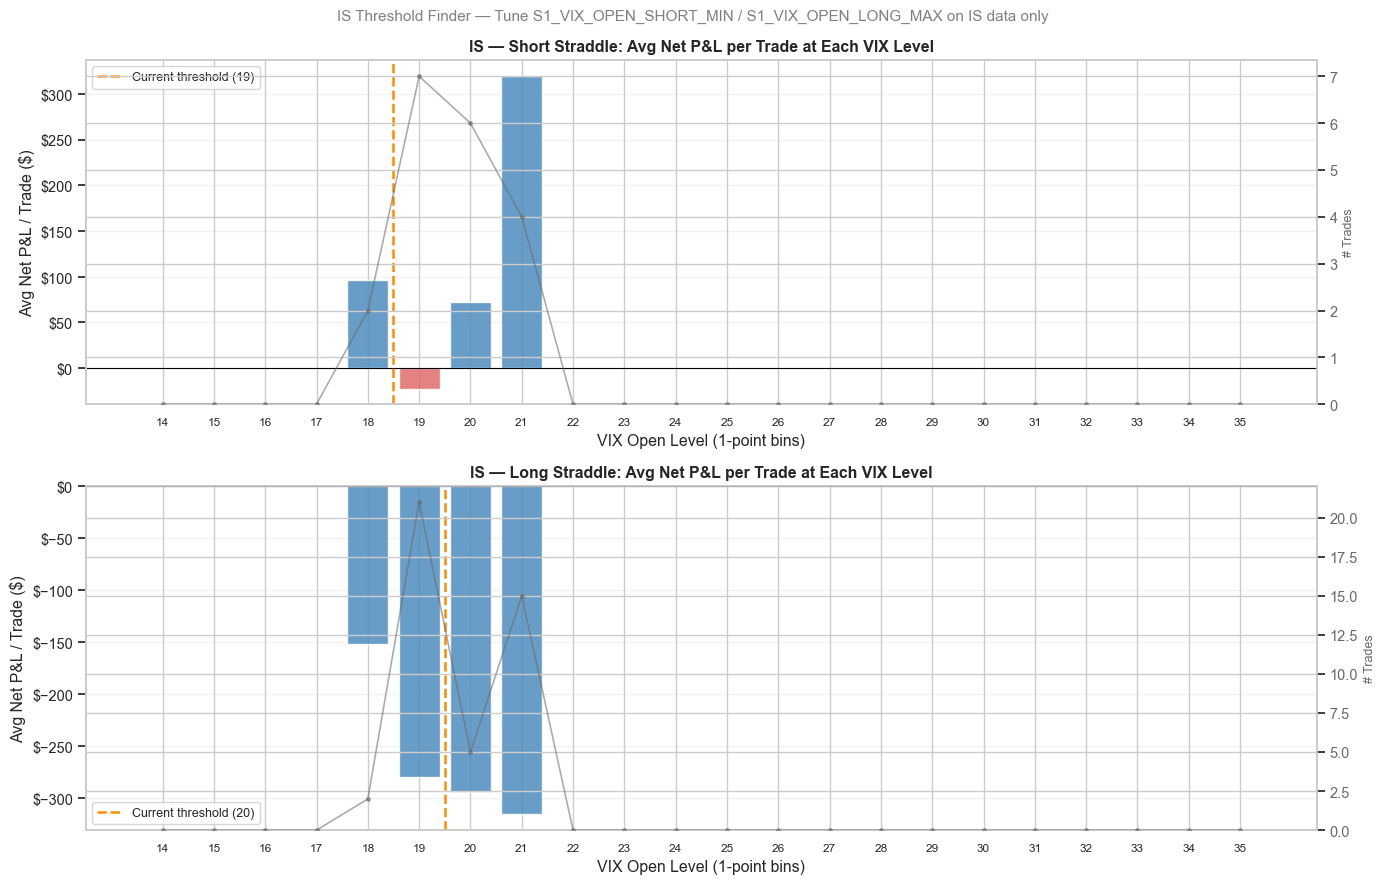

In [16]:
# ── IS: Fine-grained threshold finder ─────────────────────────────────────
tl_is["vix_bin_fine"] = pd.cut(tl_is["vix_open"], bins=fine_bins, labels=fine_labels, right=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

for ax, side in zip(axes, ["short", "long"]):
    sub   = tl_is[tl_is["side"] == side]
    stats = (
        sub.groupby("vix_bin_fine", observed=True)["pnl_net"]
        .agg(avg_pnl="mean", n="count")
        .reindex(fine_labels)
        .reset_index()
    )

    xs    = np.arange(len(stats))
    bar_c = [SIDE_COLOR[side] if (v is not None and not np.isnan(v) and v >= 0)
             else "#dddddd" if (v is None or np.isnan(v))
             else "#e06c6c" if side == "short" else "#4e8cbe"
             for v in stats["avg_pnl"]]
    ax.bar(xs, stats["avg_pnl"].fillna(0), color=bar_c, alpha=0.85, edgecolor="white", zorder=2)

    ax2 = ax.twinx()
    ax2.plot(xs, stats["n"].fillna(0), color="dimgray", linewidth=1.2,
             marker=".", markersize=5, alpha=0.55, label="# Trades", zorder=3)
    ax2.set_ylabel("# Trades", color="dimgray", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="dimgray")
    ax2.set_ylim(bottom=0)

    thresh = CURRENT_THRESH[side]
    thresh_idx = next((i for i, lbl in enumerate(stats["vix_bin_fine"])
                       if lbl is not None and float(lbl) >= thresh), None)
    if thresh_idx is not None:
        ax.axvline(thresh_idx - 0.5, color="darkorange", linestyle="--",
                   linewidth=1.8, zorder=4, label=f"Current threshold ({thresh:.0f})")

    ax.axhline(0, color="black", linewidth=0.8, zorder=3)
    ax.set_xticks(xs)
    ax.set_xticklabels(stats["vix_bin_fine"], rotation=0, fontsize=8.5)
    ax.set_xlabel("VIX Open Level (1-point bins)")
    ax.set_ylabel("Avg Net P&L / Trade ($)")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    ax.set_title(
        f"IS — {'Short' if side=='short' else 'Long'} Straddle: Avg Net P&L per Trade at Each VIX Level",
        fontweight="bold"
    )
    ax.grid(True, axis="y", alpha=0.25, zorder=1)
    ax.legend(fontsize=9, loc="upper left" if side == "short" else "lower left")

fig.suptitle("IS Threshold Finder — Tune S1_VIX_OPEN_SHORT_MIN / S1_VIX_OPEN_LONG_MAX on IS data only",
             fontsize=11, color="gray")
fig.tight_layout()
plt.show()